In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset, Dataset
import re
from trl import maybe_apply_chat_template
from trl.extras.vllm_client import VLLMClient
from types import SimpleNamespace
from tqdm import tqdm
import numpy as np
import math

INFO 08-01 00:54:31 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 08-01 00:54:38 [__init__.py:239] Automatically detected platform cuda.


# run from terminal
```
## PRM-COMP
export localpath20=/fsx/ubuntu/users/mghmr/Intuitor/open-r1-intuitor/data/Qwen2.5-3B-PRM-COMP_Reward/checkpoint-20/
export localpath30=/fsx/ubuntu/users/mghmr/Intuitor/open-r1-intuitor/data/Qwen2.5-3B-PRM-COMP_Reward/checkpoint-30/
export localpath40=/fsx/ubuntu/users/mghmr/Intuitor/open-r1-intuitor/data/Qwen2.5-3B-PRM-COMP_Reward/checkpoint-40/
export localpath50=/fsx/ubuntu/users/mghmr/Intuitor/open-r1-intuitor/data/Qwen2.5-3B-PRM-COMP_Reward/checkpoint-50/
export localpath58=/fsx/ubuntu/users/mghmr/Intuitor/open-r1-intuitor/data/Qwen2.5-3B-PRM-COMP_Reward/checkpoint-58/
export localpath10=/fsx/ubuntu/users/mghmr/Intuitor/open-r1-intuitor/data/Qwen2.5-3B-PRM-COMP_Reward/checkpoint-10/

## Intuitor
export localpath20=/fsx/ubuntu/users/mghmr/Intuitor/open-r1-intuitor/data/Qwen2.5-Intuitor-3B/checkpoint-20/
export localpath30=/fsx/ubuntu/users/mghmr/Intuitor/open-r1-intuitor/data/Qwen2.5-Intuitor-3B/checkpoint-30/
export localpath40=/fsx/ubuntu/users/mghmr/Intuitor/open-r1-intuitor/data/Qwen2.5-Intuitor-3B/checkpoint-40/
export localpath50=/fsx/ubuntu/users/mghmr/Intuitor/open-r1-intuitor/data/Qwen2.5-Intuitor-3B/checkpoint-50/
export localpath58=/fsx/ubuntu/users/mghmr/Intuitor/open-r1-intuitor/data/Qwen2.5-Intuitor-3B/checkpoint-58/
export localpath10=/fsx/ubuntu/users/mghmr/Intuitor/open-r1-intuitor/data/Qwen2.5-Intuitor-3B/checkpoint-10/


nohup env CUDA_VISIBLE_DEVICES=0 trl vllm-serve --model $localpath20 --port 8001 > delete_later/temp0.log 2>&1 & VLLM_PID=$!
nohup env CUDA_VISIBLE_DEVICES=1 trl vllm-serve --model $localpath30 --port 8002 > delete_later/temp1.log 2>&1 & VLLM_PID=$!
nohup env CUDA_VISIBLE_DEVICES=2 trl vllm-serve --model $localpath40 --port 8003 > delete_later/temp2.log 2>&1 & VLLM_PID=$!
nohup env CUDA_VISIBLE_DEVICES=3 trl vllm-serve --model $localpath50 --port 8004 > delete_later/temp3.log 2>&1 & VLLM_PID=$!
nohup env CUDA_VISIBLE_DEVICES=4 trl vllm-serve --model $localpath58 --port 8005 > delete_later/temp4.log 2>&1 & VLLM_PID=$!
nohup env CUDA_VISIBLE_DEVICES=5 trl vllm-serve --model $localpath10 --port 8006 > delete_later/temp5.log 2>&1 & VLLM_PID=$!
nohup env CUDA_VISIBLE_DEVICES=6 trl vllm-serve --model Qwen/Qwen2.5-3B --port 8007 > delete_later/temp6.log 2>&1 & VLLM_PID=$!
```

In [2]:
# dataset_name = "DigitalLearningGmbH/MATH-lighteval"
dataset_name = "HuggingFaceH4/MATH-500"

In [3]:
def make_conversation(example):
    prompt = []
    
    system_prompt = "You are a helpful AI Assistant, designed to provided well-reasoned and detailed responses. You FIRST think about the reasoning process step by step and then provide the user with the answer. Please enclose your final answer in the box: \\boxed{Your Answer}. Please stop generation immediately after outputing the box."
    
    prompt.append({"role": "system", "content": system_prompt})
    prompt.append({"role": "user", "content": example["problem"]})
    # prompt.append({"role": "assistant", "content": example["solution"]})
    return {"prompt": prompt}

In [14]:
# model = AutoModelForCausalLM.from_pretrained(local_path, torch_dtype=torch.float16, device_map='balanced')
# model_20 = LLM(
#         model=local_path_20,
#         dtype="bfloat16",
#         tensor_parallel_size=1)
model_0 = VLLMClient("0.0.0.0", 8007, connection_timeout=600)
model_10 = VLLMClient("0.0.0.0", 8006, connection_timeout=600)
model_20 = VLLMClient("0.0.0.0", 8001, connection_timeout=600)
model_30 = VLLMClient("0.0.0.0", 8002, connection_timeout=600)
model_40 = VLLMClient("0.0.0.0", 8003, connection_timeout=600)
model_50 = VLLMClient("0.0.0.0", 8004, connection_timeout=600)
model_58 = VLLMClient("0.0.0.0", 8005, connection_timeout=600)

In [4]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B")

In [5]:
dataset = load_dataset(dataset_name, "default")

In [6]:
new_dataset = dataset["test"].to_dict()

In [7]:
# remove_boxes = re.compile(r'(?s)^(.*?)\\boxed\{')  # (?s) == re.DOTALL
remove_boxes = re.compile(r'(?s)^(.*?)\s*\$?\s*\\boxed\{')
all_solutions = new_dataset["solution"]
m = list(map(lambda tex_string: remove_boxes.search(tex_string), all_solutions))   # use search, not match

In [8]:
before_box = [each.group(1) if each else '' for each in m]

In [9]:
new_dataset['solution'] = before_box

In [10]:
new_dataset = Dataset.from_dict(new_dataset)

In [11]:
new_dataset = new_dataset.map(make_conversation)

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [12]:
new_dataset

Dataset({
    features: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id', 'prompt'],
    num_rows: 500
})

In [13]:
prompts_text = [maybe_apply_chat_template(example, tokenizer)["prompt"] for example in new_dataset]
prompts_text[0]

'<|im_start|>system\nYou are a helpful AI Assistant, designed to provided well-reasoned and detailed responses. You FIRST think about the reasoning process step by step and then provide the user with the answer. Please enclose your final answer in the box: \\boxed{Your Answer}. Please stop generation immediately after outputing the box.<|im_end|>\n<|im_start|>user\nConvert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \\le \\theta < 2 \\pi.$<|im_end|>\n<|im_start|>assistant\n'

In [4]:
# models = [model_0, model_10, model_20, model_30, model_40, model_50, model_58]
# models = [model_10, model_20, model_30, model_40, model_50, model_58]
# sampling_params = {'temperature':0, 'max_tokens':1024, 'logprobs':1}

# outputs = []
# for model in tqdm(models):
#     outputs_raw = model.generate(prompts_text, generation_kwargs=sampling_params)
#     output_obj = [SimpleNamespace(**output) for output in outputs_raw]
#     outputs.append(output_obj)

In [ ]:
# from tqdm import tqdm

# batch_size = 32


# prompt_ids, prompt_mask = prompt_inputs['input_ids'], prompt_inputs['attention_mask']
# for i in tqdm(range(0, len(prompts_text), batch_size)):
#     torch.cuda.empty_cache()
#     start, end = i, i + batch_size           # no “+1”
#     # with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.bfloat16):
#     #     curr_generation = model(prompt_ids[start:end], prompt_mask[start:end], logits_to_keep=1)
#     curr_generation = model.generate(prompts_text[start:end], SamplingParams(temperature=0, max_tokens=64))
#     completion.extend(curr_generation.)
#     completion_logits.extend(curr_generation.logits)

In [5]:
# all_completions = []
# completion_logprobs = []
# # count_boxes = 0
# all_logprobs = []
# all_ratios = []
# boxed_token = '79075'
# for all_output in outputs:
#     completion = []
#     count_boxes = 0
#     for output in all_output:
#         completion.append(output.text)
#         completion_logprobs.append(output.logprobs)
#         if "boxed" in output.text:
#             temp_dict = {list(each.keys())[0]: each[list(each.keys())[0]] for each in output.logprobs}
#             count_boxes += 1
#             all_logprobs.append(temp_dict[boxed_token])
#     all_completions.append(completion)
#     all_ratios.append(count_boxes/len(prompts_text))

In [6]:
# all_ratios

In [15]:
# --------------------------------------------------------------------
# 0.  SET‑UP
# --------------------------------------------------------------------
from types import SimpleNamespace
import math, torch, pandas as pd
from tqdm.auto import tqdm

# token‑id of "\boxed{"  (keep as *string* because vLLM logprobs use str keys)
boxed_token = "79075"

# training checkpoints must line up with the order in `models`
# ckpt_tags   = ["0", "10", "20", "30", "40", "50", "58"]
ckpt_tags   = ["0", "10", "20", "30", "40", "50", "58"]

models = [model_0, model_10, model_20, model_30, model_40, model_50, model_58]

In [16]:
# raise logprobs so the boxed token is usually captured
sampling_params = {'temperature': 0,
                   'max_tokens' : 1024,
                   'logprobs'   : 20}

# --------------------------------------------------------------------
# 1.  GENERATE COMPLETIONS (one batch per checkpoint)
# --------------------------------------------------------------------
outputs = []                                   # holds per‑checkpoint batches
for model in tqdm(models, desc="generation"):
    outputs_raw = model.generate(prompts_text,
                                 generation_kwargs=sampling_params)
    output_obj  = [SimpleNamespace(**o) for o in outputs_raw]
    outputs.append(output_obj)                 # len == len(models)

generation:   0%|          | 0/7 [00:00<?, ?it/s]

In [17]:
stats = []
for tag, batch in zip(ckpt_tags, outputs):                   # batch = list[out]
    n_prompts           = len(batch)
    n_hits, nll_sum     = 0, 0.0
    nll_count           = 0
    pos_list            = []                                 # where \boxed{ hits

    for out in batch:                                        # -------- 1 prompt
        for idx, topk in enumerate(out.logprobs):            # scan ALL tokens
            # -------------- chosen token at this position -------------------
            # topk is dict {token_id: {'logprob': float, 'rank': int, ...}, …}
            # chose the one with rank==1 (fast) or highest logprob
            chosen_id, chosen_info = max(
                topk.items(),
                key=lambda kv: (-kv[1].get('rank', 999999), kv[1]['logprob'])
            )

            # ---- did the model *actually* emit \boxed{  ?
            if chosen_id == boxed_token:
                n_hits     += 1
                nll_sum    += -chosen_info['logprob']        # −log P
                nll_count  += 1
                pos_list.append(idx)
                break                                        # stop scanning
        # (if never broken, prompt counts as miss)

    boxed_freq  = n_hits / n_prompts
    boxed_nll   = nll_sum / nll_count if nll_count else float("nan")
    avg_pos     = sum(pos_list)/len(pos_list) if pos_list else float("nan")

    stats.append(dict(
        step        = int(tag),
        boxed_freq  = boxed_freq,
        boxed_nll   = boxed_nll,
        avg_pos     = avg_pos,
        hits        = n_hits,
        prompts     = n_prompts,
    ))

# --------------------------------------------------------------------
# 3   RESULTS
# --------------------------------------------------------------------
stats_df = pd.DataFrame(stats).set_index("step").sort_index()


In [18]:
stats_df

,boxed_freq,boxed_nll,avg_pos,hits,prompts
step,,,,,
0,0.724,0.037072,415.005525,362,500
10,0.802,0.019314,481.815461,401,500
20,0.844,0.014447,487.345972,422,500
30,0.858,0.022475,483.494172,429,500
40,0.810,0.047460,484.760494,405,500
50,0.814,0.049760,469.120393,407,500
58,0.792,0.040319,469.219697,396,500


<Axes: xlabel='step'>

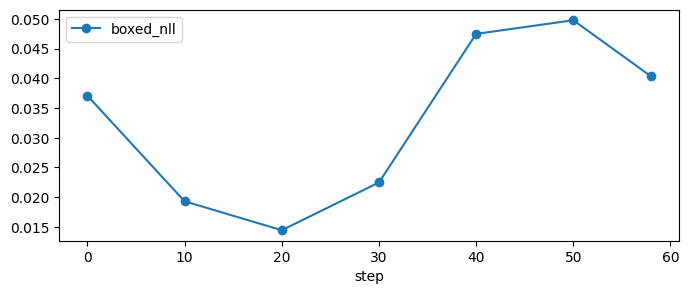

In [21]:
# new_df = pd.DataFrame([{'step': 0, 'boxed_nll': 0.040, 'boxed_freq': None, 'avg_pos': None, 'hits': None, 'prompts': 500}])

# stats_df = pd.concat([new_df, stats_df])

stats_df[["boxed_nll"]].plot(marker="o", figsize=(8,3))

In [20]:
stats_df.to_csv("boxed_freq_nll_prm.csv")

<Axes: xlabel='step'>

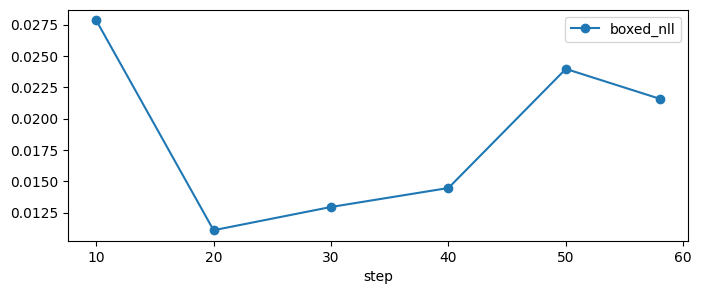

In [18]:
stats_df_2[["boxed_nll"]].plot(secondary_y="boxed_freq",
                                          marker="o", figsize=(8,3))

In [26]:
prm_df = pd.read_csv('boxed_freq_nll_prm.csv')
int_df = pd.read_csv('boxed_freq_nll_int.csv')

In [28]:
prm_df["box_prob"] = np.exp(-prm_df["boxed_nll"])   # 0 – 1 certainty scale
# optional strict-recall column
prm_df["recall_99"] = prm_df["boxed_freq"].where(prm_df["box_prob"] >= 0.99, 0.0)
prm_df.to_csv("prm_wprob.csv", index=False)


int_df["box_prob"] = np.exp(-int_df["boxed_nll"])   # 0 – 1 certainty scale
# optional strict-recall column
int_df["recall_99"] = int_df["boxed_freq"].where(int_df["box_prob"] >= 0.99, 0.0)
int_df.to_csv("int_wprob.csv", index=False)

In [30]:
prm_df, int_df

(   step  boxed_freq  boxed_nll     avg_pos  hits  prompts  box_prob  recall_99
 0     0       0.724   0.037072  415.005525   362      500  0.963607        0.0
 1    10       0.802   0.019314  481.815461   401      500  0.980871        0.0
 2    20       0.844   0.014447  487.345972   422      500  0.985656        0.0
 3    30       0.858   0.022475  483.494172   429      500  0.977776        0.0
 4    40       0.810   0.047460  484.760494   405      500  0.953648        0.0
 5    50       0.814   0.049760  469.120393   407      500  0.951457        0.0
 6    58       0.792   0.040319  469.219697   396      500  0.960483        0.0,
    step  boxed_freq  boxed_nll     avg_pos  hits  prompts  box_prob  recall_99
 0     0       0.696   0.039848  410.669540   348      500  0.960936      0.000
 1    10       0.822   0.005948  530.527981   411      500  0.994069      0.822
 2    20       0.774   0.004705  579.087855   387      500  0.995306      0.774
 3    30       0.730   0.012065  578.82

In [23]:
stats_df

,boxed_freq,boxed_nll,avg_pos,hits,prompts
step,,,,,
0,0.724,0.037072,415.005525,362,500
10,0.802,0.019314,481.815461,401,500
20,0.844,0.014447,487.345972,422,500
30,0.858,0.022475,483.494172,429,500
40,0.810,0.047460,484.760494,405,500
50,0.814,0.049760,469.120393,407,500
58,0.792,0.040319,469.219697,396,500


In [16]:
tokenizer = AutoTokenizer.from_pretrained("LiquidAI/LFM2-1.2B")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/967 [00:00<?, ?B/s]

In [17]:
[maybe_apply_chat_template(example, tokenizer)['prompt'] for example in new_dataset][0]

'<|startoftext|><|im_start|>system\nYou are a helpful AI Assistant, designed to provided well-reasoned and detailed responses. You FIRST think about the reasoning process step by step and then provide the user with the answer. Please enclose your final answer in the box: \\boxed{Your Answer}. Please stop generation immediately after outputing the box.<|im_end|>\n<|im_start|>user\nConvert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \\le \\theta < 2 \\pi.$<|im_end|>\n<|im_start|>assistant\n'

In [18]:
### for transitional words
# raise logprobs so the boxed token is usually captured
sampling_params = {'temperature': 0,
                   'max_tokens' : 1024,
                   'logprobs'   : None}

# --------------------------------------------------------------------
# 1.  GENERATE COMPLETIONS (one batch per checkpoint)
# --------------------------------------------------------------------
outputs = []                                   # holds per‑checkpoint batches
for model in tqdm(models, desc="generation"):
    outputs_raw = model.generate(prompts_text,
                                 generation_kwargs=sampling_params)
    output_obj  = [SimpleNamespace(**o) for o in outputs_raw]
    outputs.append(output_obj)  

generation:   0%|          | 0/7 [00:00<?, ?it/s]

In [24]:
# -------------------------------------------------------------
# 0  TOKEN IDS FOR TRANSITION WORDS  (run once, reuse tokenizer)
# -------------------------------------------------------------
pivot_words = [
    " but", " But", " however", " However", " although", " Although",
    " though", " Though", " yet", " Yet", " still", " Still",
    " nevertheless", " Nevertheless", " instead", " Instead",
    " wait", " Wait",
]
pivot_id_set = {
    tokenizer.encode(w, add_special_tokens=False)[0]
    for w in pivot_words
    if len(tokenizer.encode(w, add_special_tokens=False)) == 1
}

In [25]:
# -------------------------------------------------------------
# 1  FREQUENCY PER CHECKPOINT  (chosen-token lists only)
#    Assumes each `out` exposes `out.token_ids` (or similar)
# -------------------------------------------------------------
freq_stats = []
for tag, batch in zip(ckpt_tags, outputs):           # batch = list[out]
    n_prompts_with_pivot = 0

    for out in batch:                                # one prompt
        for tid in out.token_ids:
            if tid in pivot_id_set:
                n_prompts_with_pivot += 1
                break                                # count prompt once

    freq_stats.append({
        "step":       int(tag),
        "pivot_freq": n_prompts_with_pivot / len(batch),
    })

pivot_freq_df_2 = (
    pd.DataFrame(freq_stats)
      .set_index("step")
      .sort_index()
)

In [26]:
pivot_freq_df_2

,pivot_freq
step,
0,0.080
10,0.104
20,0.112
30,0.076
40,0.104
50,0.094
58,0.092


In [27]:
pivot_freq_df_2.to_csv('pivot_freq_prm.csv')

In [28]:
pivot_freq_df

,pivot_freq
step,
0,0.078
10,0.116
20,0.114
30,0.084
40,0.086
50,0.074
58,0.074


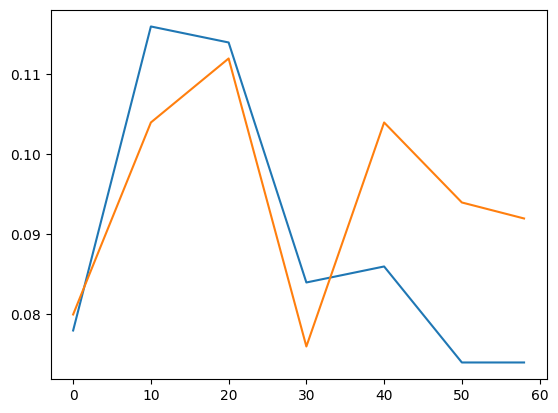

In [35]:
import matplotlib.pyplot as plt
plt.plot(pivot_freq_df)
plt.plot(pivot_freq_df_2)

In [19]:
import re
re_pivots = re.compile(
    r"\b(?:but|however|although|yet|still|nevertheless"
    r"|nonetheless|instead|rather|conversely|alternatively"
    r"|on the other hand|wait)\b", re.I)

freq_stats_temp = []
for tag, batch in zip(ckpt_tags, outputs):             # batch = List[out]
    prompt_hits, pivot_tokens, total_tokens = 0, 0, 0

    for out in batch:
        text = tokenizer.decode(out.token_ids, skip_special_tokens=True)
        total_tokens += len(out.token_ids)

        # binary hit (presence)
        if re_pivots.search(text):
            prompt_hits += 1

        # density (count every pivot word)
        pivot_tokens += len(re_pivots.findall(text))

    freq_stats_temp.append({
        "step":            int(tag),
        "pivot_presence":  prompt_hits / len(batch),      # ≥1 per prompt
        "pivot_density":   pivot_tokens / total_tokens,   # pivots per token
    })

pivot_df_int = (
    pd.DataFrame(freq_stats_temp)
      .set_index("step")
      .sort_index()
)


In [39]:
pivot_df_prm

,pivot_presence,pivot_density
step,,
0,0.092,0.000410
10,0.132,0.000449
20,0.132,0.000378
30,0.106,0.000272
40,0.124,0.000332
50,0.114,0.000352
58,0.112,0.000305


In [20]:
pivot_df_int

,pivot_presence,pivot_density
step,,
0,0.092,0.000428
10,0.126,0.000306
20,0.110,0.000239
30,0.098,0.000219
40,0.074,0.000147
50,0.076,0.000158
58,0.076,0.000155


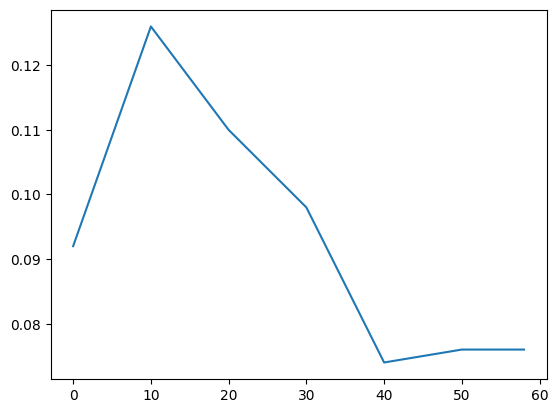

In [22]:
import matplotlib.pyplot as plt
plt.plot(pivot_df_int['pivot_presence'])

In [23]:
pivot_df_int.to_csv('pivot_accurate_int.csv')